In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

hdf_dir = '/content/drive/MyDrive/WildfireProject raw_hdf'
output_dir = '/content/drive/MyDrive/WildfireProject/tifs'

os.makedirs(output_dir, exist_ok=True)

In [ ]:
print("Files in output (tifs) folder:")
print(os.listdir(output_dir))

Files in output (tifs) folder:
['MCD64A1.A2022213.h09v04.061.2022284175954_mask.tif', 'MCD64A1.A2022213.h08v05.061.2022284175115_mask.tif', 'MCD64A1.A2022182.h09v04.061.2022251141020_mask.tif', 'MCD64A1.A2022244.h08v04.061.2022315163506_mask.tif', 'MCD64A1.A2022213.h08v04.061.2022284164918_mask.tif', 'MCD64A1.A2022182.h08v04.061.2022251143527_mask.tif', 'MCD64A1.A2022182.h08v05.061.2022251144409_mask.tif', 'MCD64A1.A2022274.h08v04.061.2022351050405_mask.tif', 'MCD64A1.A2022244.h08v05.061.2022315164354_mask.tif', 'MCD64A1.A2022244.h09v04.061.2022315175943_mask.tif', 'MCD64A1.A2022274.h08v05.061.2022351060150_mask.tif', 'MCD64A1.A2022274.h09v04.061.2022351073041_mask.tif', 'masks']


## Acquiring Data

### Getting raw images

In [ ]:
# Get original contents from hdf_raw files

import os
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

burn_hdf_dir = '/content/drive/MyDrive/WildfireProject raw_hdf'
burn_png_dir = '/content/drive/MyDrive/WildfireProject/png_outputs_burn'
os.makedirs(burn_png_dir, exist_ok=True)

def convert_burn_to_png(hdf_path, save_dir):
    dataset = gdal.Open(hdf_path)
    subdatasets = dataset.GetSubDatasets()

    if not subdatasets:
        print(f"No subdatasets in {os.path.basename(hdf_path)}")
        return

    # Get burn date layer
    burn_data = gdal.Open(subdatasets[0][0]).ReadAsArray()

    # Replace invalid values (>366 or <1) with 0
    burn_data = np.where((burn_data > 366) | (burn_data < 1), 0, burn_data)

    # Normalize to 0–1 for grayscale
    norm_burn = np.clip(burn_data / 366.0, 0, 1)

    fname = os.path.basename(hdf_path).replace('.hdf', '.png')
    out_path = os.path.join(save_dir, f"burnmask_{fname}")

    plt.imsave(out_path, norm_burn, cmap='gray')
    print(f"Saved burn mask: {out_path}")

burn_files = sorted([f for f in os.listdir(burn_hdf_dir) if f.endswith('.hdf')])
print(f"Converting {len(burn_files)} burn HDFs to PNGs...")

for f in tqdm(burn_files):
    convert_burn_to_png(os.path.join(burn_hdf_dir, f), burn_png_dir)

Converting 12 burn HDFs to PNGs...


  8%|▊         | 1/12 [00:01<00:19,  1.76s/it]

Saved burn mask: /content/drive/MyDrive/WildfireProject/png_outputs_burn/burnmask_MCD64A1.A2022182.h08v04.061.2022251143527.png


 17%|█▋        | 2/12 [00:03<00:17,  1.71s/it]

Saved burn mask: /content/drive/MyDrive/WildfireProject/png_outputs_burn/burnmask_MCD64A1.A2022182.h08v05.061.2022251144409.png


...

Saved burn mask: /content/drive/MyDrive/WildfireProject/png_outputs_burn/burnmask_MCD64A1.A2022274.h08v04.061.2022351050405.png


 92%|█████████▏| 11/12 [00:18<00:01,  1.78s/it]

Saved burn mask: /content/drive/MyDrive/WildfireProject/png_outputs_burn/burnmask_MCD64A1.A2022274.h08v05.061.2022351060150.png


100%|██████████| 12/12 [00:20<00:00,  1.68s/it]

Saved burn mask: /content/drive/MyDrive/WildfireProject/png_outputs_burn/burnmask_MCD64A1.A2022274.h09v04.061.2022351073041.png


In [ ]:
# Get original contents from hdf pre burn raw files

from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

preburn_hdf_dir = '/content/drive/MyDrive/WildfireProject preburn_hdf'
burn_hdf_dir = '/content/drive/MyDrive/WildfireProject raw_hdf'
save_dir = '/content/drive/MyDrive/WildfireProject/png_outputs'
os.makedirs(save_dir, exist_ok=True)

# Helper function to process HDF and save PNG
def save_rgb_as_png(hdf_path, prefix, out_dir):
    dataset = gdal.Open(hdf_path)
    subdatasets = dataset.GetSubDatasets()
    bands = {}

    for sds_path, desc in subdatasets:
        if 'sur_refl_b01' in sds_path:
            bands['R'] = gdal.Open(sds_path).ReadAsArray().astype('float32')
        elif 'sur_refl_b04' in sds_path:
            bands['G'] = gdal.Open(sds_path).ReadAsArray().astype('float32')
        elif 'sur_refl_b03' in sds_path:
            bands['B'] = gdal.Open(sds_path).ReadAsArray().astype('float32')

    if len(bands) < 3:
        print(f"Skipping {os.path.basename(hdf_path)} (missing bands)")
        return

    rgb = np.stack([bands['R'], bands['G'], bands['B']], axis=-1)
    rgb = np.clip(rgb / 10000.0, 0, 1)

    filename = os.path.basename(hdf_path).replace('.hdf', '.png')
    save_path = os.path.join(out_dir, f"{prefix}_{filename}")

    plt.imsave(save_path, rgb)
    print(f"Saved {save_path}")

# Burn Images
burn_files = sorted([f for f in os.listdir(burn_hdf_dir) if f.endswith('.hdf')])
print(f"\nGenerating PNGs for {len(burn_files)} burn HDFs:")
for file in tqdm(burn_files):
    save_rgb_as_png(os.path.join(burn_hdf_dir, file), "burn", save_dir)

# Preburn Images
preburn_files = sorted([f for f in os.listdir(preburn_hdf_dir) if f.endswith('.hdf')])
print(f"\nGenerating PNGs for {len(preburn_files)} preburn HDFs:")
for file in tqdm(preburn_files):
    save_rgb_as_png(os.path.join(preburn_hdf_dir, file), "preburn", save_dir)



Generating PNGs for 12 burn HDFs:


100%|██████████| 12/12 [00:00<00:00, 89.41it/s]


Skipping MCD64A1.A2022182.h08v04.061.2022251143527.hdf (missing bands)
Skipping MCD64A1.A2022182.h08v05.061.2022251144409.hdf (missing bands)
Skipping MCD64A1.A2022182.h09v04.061.2022251141020.hdf (missing bands)
Skipping MCD64A1.A2022213.h08v04.061.2022284164918.hdf (missing bands)
Skipping MCD64A1.A2022213.h08v05.061.2022284175115.hdf (missing bands)
Skipping MCD64A1.A2022213.h09v04.061.2022284175954.hdf (missing bands)
Skipping MCD64A1.A2022244.h08v04.061.2022315163506.hdf (missing bands)
Skipping MCD64A1.A2022244.h08v05.061.2022315164354.hdf (missing bands)
Skipping MCD64A1.A2022244.h09v04.061.2022315175943.hdf (missing bands)
Skipping MCD64A1.A2022274.h08v04.061.2022351050405.hdf (missing bands)
Skipping MCD64A1.A2022274.h08v05.061.2022351060150.hdf (missing bands)
Skipping MCD64A1.A2022274.h09v04.061.2022351073041.hdf (missing bands)

Generating PNGs for 6 preburn HDFs:


 17%|█▋        | 1/6 [00:03<00:18,  3.76s/it]

Saved /content/drive/MyDrive/WildfireProject/png_outputs/preburn_MOD09GA.A2022180.h09v04.061.2022182033640.png


...

Saved /content/drive/MyDrive/WildfireProject/png_outputs/preburn_MOD09GA.A2022189.h08v04.061.2022191043930.png


 83%|████████▎ | 5/6 [00:18<00:03,  3.73s/it]

Saved /content/drive/MyDrive/WildfireProject/png_outputs/preburn_MOD09GA.A2022189.h08v05.061.2022191041255.png


100%|██████████| 6/6 [00:21<00:00,  3.64s/it]

Saved /content/drive/MyDrive/WildfireProject/png_outputs/preburn_MOD09GA.A2022189.h09v04.061.2022191044549.png


### installing required libraries

In [ ]:
!apt-get install -y gdal-bin python3-gdal
!pip install rasterio

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 34 not upgraded.
Need to get 5,055 kB of archives.
After this operation, 25.1 MB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.6.4+dfsg-1~jammy0 [1,027 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.6.4+dfsg-1~jammy0 [561 kB]
Fetched 5,055 kB in 1s (5,915 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 126333 files and directories curren

## Extracting Burn Date Masks from HDF

In [ ]:
import os
import numpy as np
import rasterio
from osgeo import gdal
from rasterio.transform import from_origin

hdf_dir = '/content/drive/MyDrive/WildfireProject raw_hdf'
output_dir = '/content/drive/MyDrive/WildfireProject/tifs'
os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(hdf_dir):
    if filename.endswith('.hdf'):
        hdf_path = os.path.join(hdf_dir, filename)
        print(f"Processing: {filename}")

        # Open HDF with GDAL
        hdf_dataset = gdal.Open(hdf_path)
        if not hdf_dataset:
            print(f"Could not open {filename}, skipping.")
            continue

        # Find the "Burn Date" subdataset
        subdatasets = hdf_dataset.GetSubDatasets()
        burn_dataset_path = None
        for subdataset in subdatasets:
            if 'Burn Date' in subdataset[0]:
                burn_dataset_path = subdataset[0]
                break

        if not burn_dataset_path:
            print(f"'Burn Date' not found in {filename}, skipping.")
            continue

        # Open the Burn Date subdataset
        burn_ds = gdal.Open(burn_dataset_path)
        burn_array = burn_ds.ReadAsArray()

        # Clean values: 0 = unburned, >366 = invalid
        burn_array = np.where(burn_array > 366, 0, burn_array)

        # Convert to binary mask
        binary_mask = (burn_array > 0).astype(np.uint8)

        # Save as GeoTIFF
        out_path = os.path.join(output_dir, filename.replace('.hdf', '_mask.tif'))

        transform = from_origin(0, 0, 1, 1)  # dummy transform

        with rasterio.open(
            out_path,
            'w',
            driver='GTiff',
            height=binary_mask.shape[0],
            width=binary_mask.shape[1],
            count=1,
            dtype=binary_mask.dtype,
            transform=transform,
        ) as dst:
            dst.write(binary_mask, 1)

        print(f"Saved mask: {out_path}")

Processing: MCD64A1.A2022182.h08v04.061.2022251143527.hdf


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022182.h08v04.061.2022251143527_mask.tif
Processing: MCD64A1.A2022182.h08v05.061.2022251144409.hdf
Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022182.h08v05.061.2022251144409_mask.tif
Processing: MCD64A1.A2022182.h09v04.061.2022251141020.hdf
Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022182.h09v04.061.2022251141020_mask.tif
Processing: MCD64A1.A2022213.h08v04.061.2022284164918.hdf
Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022213.h08v04.061.2022284164918_mask.tif
Processing: MCD64A1.A2022213.h08v05.061.2022284175115.hdf
Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022213.h08v05.061.2022284175115_mask.tif
Processing: MCD64A1.A2022213.h09v04.061.2022284175954.hdf
Saved mask: /content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022213.h09v04.061.2022284175954_mask.tif
Processing: MCD64A1.A2022244.h08v04.061.2022315163506.hdf
Saved mask

## Visualising burn mask GEOTIFF

In [ ]:
sample_path = '/content/drive/MyDrive/WildfireProject/tifs/MCD64A1.A2022182.h08v04.061.2022251143527_mask.tif'

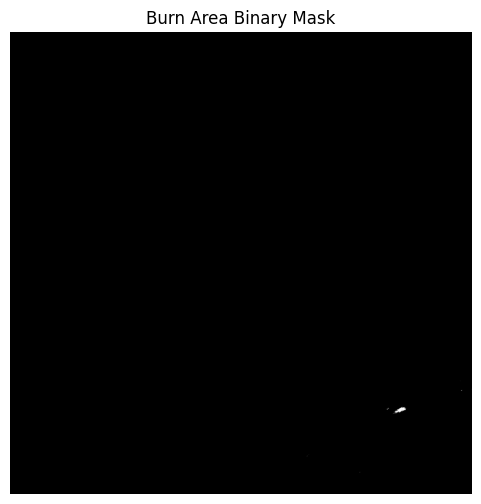

In [ ]:
import matplotlib.pyplot as plt
import rasterio

with rasterio.open(sample_path) as src:
    mask = src.read(1)

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap='gray')
plt.title('Burn Area Binary Mask')
plt.axis('off')
plt.show()

In [ ]:
#Not important
#checking how many layers are available
from osgeo import gdal


hdf_dir = '/content/drive/MyDrive/WildfireProject/raw_hdf'
hdf_files = [f for f in os.listdir(hdf_dir) if f.endswith('.hdf')]

if hdf_files:
    hdf_path = os.path.join(hdf_dir, hdf_files[0])
    hdf = gdal.Open(hdf_path)

    if hdf:  # Check if the file was opened successfully
        subdatasets = hdf.GetSubDatasets()
        for i, sds in enumerate(subdatasets):
            print(f"[{i}] {sds[0]}")
    else:
        print(f"not open HDF file: {hdf_path}")

[0] HDF4_EOS:EOS_GRID:"/content/drive/MyDrive/WildfireProject/raw_hdf/MCD64A1.A2022244.h08v05.061.2022315164354.hdf":MOD_Grid_Monthly_500m_DB_BA:"Burn Date"
[1] HDF4_EOS:EOS_GRID:"/content/drive/MyDrive/WildfireProject/raw_hdf/MCD64A1.A2022244.h08v05.061.2022315164354.hdf":MOD_Grid_Monthly_500m_DB_BA:"Burn Date Uncertainty"
[2] HDF4_EOS:EOS_GRID:"/content/drive/MyDrive/WildfireProject/raw_hdf/MCD64A1.A2022244.h08v05.061.2022315164354.hdf":MOD_Grid_Monthly_500m_DB_BA:QA
[3] HDF4_EOS:EOS_GRID:"/content/drive/MyDrive/WildfireProject/raw_hdf/MCD64A1.A2022244.h08v05.061.2022315164354.hdf":MOD_Grid_Monthly_500m_DB_BA:"First Day"
[4] HDF4_EOS:EOS_GRID:"/content/drive/MyDrive/WildfireProject/raw_hdf/MCD64A1.A2022244.h08v05.061.2022315164354.hdf":MOD_Grid_Monthly_500m_DB_BA:"Last Day"


## Visualising Tiled Images and Burn Mask

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


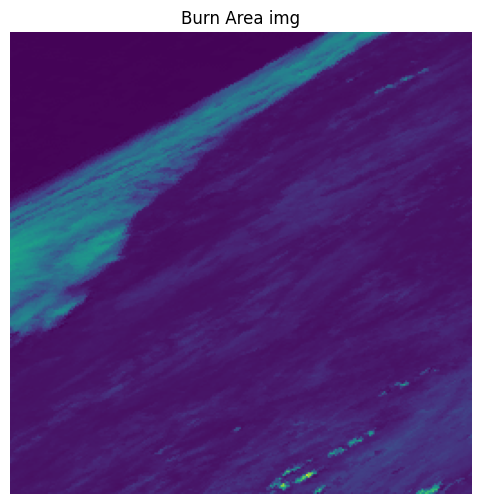

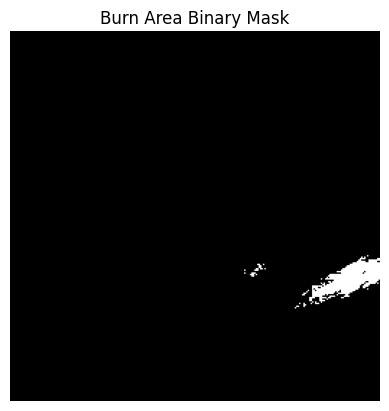

In [ ]:
path_img = '/content/drive/MyDrive/WildfireProject/tiles/train/images/h08v04_1792_1792.tif'
path_mask = '/content/drive/MyDrive/WildfireProject/tiles/train/masks/h08v04_1792_1792_mask.tif'

with rasterio.open(path_img) as src:
    img = src.read(1)
with rasterio.open(path_mask) as src:
    mask = src.read(1)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title('Burn Area img')
plt.axis('off')
plt.show()
plt.imshow(mask, cmap='grey')
plt.title('Burn Area Binary Mask')
plt.axis('off')
plt.show()

## Re Arranging the Folders


### creating mask for pre burn images

In [ ]:
import os
import rasterio
import numpy as np

# Define the directory containing your pre-burn images
preburn_image_dir = '/content/drive/MyDrive/WildfireProject/preburn_tifs'

# Define the directory where you want to save the "no fire" masks
preburn_mask_dir = '/content/drive/MyDrive/WildfireProject/preburn_masks'

# Define the integer value that will represent the "no fire" class in your masks
no_fire_class_id = 0

# Create the preburn_masks directory if it doesn't exist
os.makedirs(preburn_mask_dir, exist_ok=True)

# Iterate through each file in the preburn_image_dir
for filename in os.listdir(preburn_image_dir):
    if filename.endswith(".tif"):
        image_path = os.path.join(preburn_image_dir, filename)
        mask_filename = filename.replace(".tif", "_mask.tif")  # Create a corresponding mask filename
        mask_path = os.path.join(preburn_mask_dir, mask_filename)

        try:
            # Open the pre-burn image to get its spatial information
            with rasterio.open(image_path) as src:
                height = src.height
                width = src.width
                crs = src.crs
                transform = src.transform
                dtype = rasterio.int16

                # Create a NumPy array filled with the 'no_fire_class_id'
                no_fire_mask = np.full((height, width), no_fire_class_id, dtype=dtype)

                # Write the "no fire" mask to a new GeoTIFF file
                with rasterio.open(
                    mask_path, 'w',
                    driver='GTiff',
                    height=height,
                    width=width,
                    count=1,  # Number of bands in the mask (usually 1 for segmentation)
                    dtype=dtype,
                    crs=crs,
                    transform=transform
                ) as dst:
                    dst.write(np.expand_dims(no_fire_mask, axis=0))  # Add a band dimension

            print(f"Created no fire mask: {mask_filename} for image: {filename}")

        except rasterio.RasterioIOError as e:
            print(f"Error opening or processing image: {filename} - {e}")

print("masks for all pre-burn images.")

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Created no fire mask: MOD09GA.A2022181.h08v04.061.2022183031343_mask.tif for image: MOD09GA.A2022181.h08v04.061.2022183031343.tif
Created no fire mask: MOD09GA.A2022189.h08v05.061.2022191041255_mask.tif for image: MOD09GA.A2022189.h08v05.061.2022191041255.tif
Created no fire mask: MOD09GA.A2022189.h08v04.061.2022191043930_mask.tif for image: MOD09GA.A2022189.h08v04.061.2022191043930.tif
Created no fire mask: MOD09GA.A2022181.h08v05.061.2022183031228_mask.tif for image: MOD09GA.A2022181.h08v05.061.2022183031228.tif
Created no fire mask: MOD09GA.A2022189.h09v04.061.2022191044549_mask.tif for image: MOD09GA.A2022189.h09v04.061.2022191044549.tif
Created no fire mask: MOD09GA.A2022180.h09v04.061.2022182033640_mask.tif for image: MOD09GA.A2022180.h09v04.061.2022182033640.tif
Finished creating 'no fire' masks for all pre-burn images.


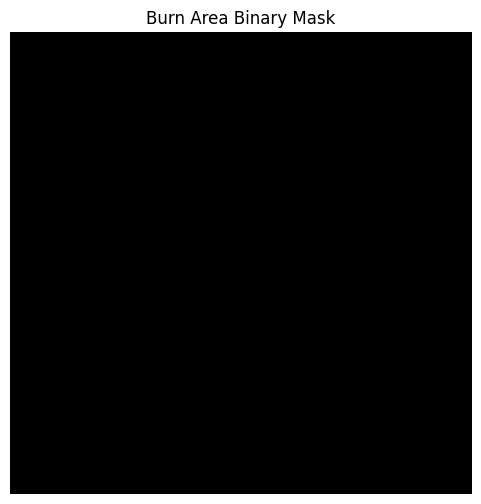

In [ ]:
# checking the pre burn masked img
path = '/content/drive/MyDrive/WildfireProject/preburn_masks/MOD09GA.A2022189.h09v04.061.2022191044549_mask.tif'

with rasterio.open(path) as src:
    mask = src.read(1)

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap='gray')
plt.title('Burn Area Binary Mask')
plt.axis('off')
plt.show()
# its dark it no white patches so its correct

## Directory setup and splitting for training

In [ ]:
import os
import rasterio
import numpy as np
from sklearn.model_selection import train_test_split
import shutil

# Define your directories and tile size
original_postburn_image_dir = '/content/drive/MyDrive/WildfireProject/tifs'
original_postburn_mask_dir = '/content/drive/MyDrive/WildfireProject/tifs/masks'
original_preburn_image_dir = '/content/drive/MyDrive/WildfireProject/preburn_tifs'
original_preburn_mask_dir = '/content/drive/MyDrive/WildfireProject/preburn_masks'

# Create a temporary directory for all tiles
temp_tiles_dir = '/content/drive/MyDrive/WildfireProject/temp_tiles'
temp_images_dir = os.path.join(temp_tiles_dir, 'images')
temp_masks_dir = os.path.join(temp_tiles_dir, 'masks')

# Final directories for train/val/test splits
output_base_dir = '/content/drive/MyDrive/WildfireProject/new_tiles'
train_image_dir = os.path.join(output_base_dir, 'train', 'images')
train_mask_dir = os.path.join(output_base_dir, 'train', 'masks')
val_image_dir = os.path.join(output_base_dir, 'val', 'images')
val_mask_dir = os.path.join(output_base_dir, 'val', 'masks')
test_image_dir = os.path.join(output_base_dir, 'test', 'images')
test_mask_dir = os.path.join(output_base_dir, 'test', 'masks')

tile_size = 256

# Create all necessary directories
for directory in [temp_images_dir, temp_masks_dir,
                 train_image_dir, train_mask_dir,
                 val_image_dir, val_mask_dir,
                 test_image_dir, test_mask_dir]:
    os.makedirs(directory, exist_ok=True)








Found 12 post-burn images and 6 pre-burn images

Processing post-burn images...

Processing pre-burn images...
Processing image: MOD09GA.A2022181.h08v04.061.2022183031343


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Created 81 tiles from MOD09GA.A2022181.h08v04.061.2022183031343
Processing image: MOD09GA.A2022189.h08v05.061.2022191041255
Created 81 tiles from MOD09GA.A2022189.h08v05.061.2022191041255
Processing image: MOD09GA.A2022189.h08v04.061.2022191043930
Created 81 tiles from MOD09GA.A2022189.h08v04.061.2022191043930
Processing image: MOD09GA.A2022181.h08v05.061.2022183031228
Created 81 tiles from MOD09GA.A2022181.h08v05.061.2022183031228
Processing image: MOD09GA.A2022189.h09v04.061.2022191044549
Created 81 tiles from MOD09GA.A2022189.h09v04.061.2022191044549
Processing image: MOD09GA.A2022180.h09v04.061.2022182033640
Created 81 tiles from MOD09GA.A2022180.h09v04.061.2022182033640

Total tiles created: 486
Train split: 340 tiles (70.0%)
Validation split: 73 tiles (15.0%)
Test split: 73 tiles (15.0%)

Moving tiles to train/val/test directories...

Validating file counts in output directories:
Train images: 340, masks: 340
Val images: 73, masks: 73
Test images: 73, masks: 73

Process completed

## Tiling both Dataset Imagery into 256x256 Patches

In [ ]:
def create_tiles(image_path, mask_path, output_image_dir, output_mask_dir, tile_size):
    try:
        image_basename = os.path.basename(image_path).replace('.tif', '')
        print(f"Processing image: {image_basename}")

        with rasterio.open(image_path) as img_file:
            image = img_file.read()  # (C, H, W)
            height = img_file.height
            width = img_file.width
            transform = img_file.transform
            crs = img_file.crs

        with rasterio.open(mask_path) as mask_file:
            mask = mask_file.read(1)  # (H, W)single band mask
            mask_transform = mask_file.transform
            mask_crs = mask_file.crs

        if crs != mask_crs or transform[:6] != mask_transform[:6]:
            print(f"Warning: CRS or transform mismatch between {image_path} and {mask_path}. Proceeding but check alignment.")

        tile_count = 0
        tiles_info = []

        for y in range(0, height, tile_size):
            for x in range(0, width, tile_size):
                x_end = min(x + tile_size, width)
                y_end = min(y + tile_size, height)

                image_tile = image[:, y:y_end, x:x_end]
                mask_tile = mask[y:y_end, x:x_end]

                # Skip tiles that are too small
                if image_tile.shape[1] < tile_size * 0.5 or image_tile.shape[2] < tile_size * 0.5:
                    continue

                # Pad tiles if they are smaller than tile_size
                pad_x = tile_size - image_tile.shape[2]
                pad_y = tile_size - image_tile.shape[1]
                if pad_x > 0 or pad_y > 0:
                    image_tile = np.pad(image_tile, ((0, 0), (0, pad_y), (0, pad_x)), mode='constant')
                    mask_tile = np.pad(mask_tile, ((0, pad_y), (0, pad_x)), mode='constant')

                # Generate unique filenames for tiles
                image_tile_filename = f"{image_basename}_tile_{x}_{y}.tif"
                mask_tile_filename = f"{image_basename}_tile_{x}_{y}_mask.tif"

                image_tile_path = os.path.join(output_image_dir, image_tile_filename)
                mask_tile_path = os.path.join(output_mask_dir, mask_tile_filename)

                # Calculate new transform for the tile
                tile_transform = rasterio.transform.from_origin(
                    transform[2] + x * transform[0],  # x_0 + col * pixel_width
                    transform[5] + y * transform[4],  # y_0 + row * pixel_height
                    transform[0],  # pixel_width
                    -transform[4]   # pixel_height (usually negative)
                )

                with rasterio.open(
                    image_tile_path, 'w',
                    driver='GTiff',
                    height=image_tile.shape[1],
                    width=image_tile.shape[2],
                    count=image_tile.shape[0],
                    dtype=image.dtype,
                    crs=crs,
                    transform=tile_transform
                ) as dst:
                    dst.write(image_tile)

                with rasterio.open(
                    mask_tile_path, 'w',
                    driver='GTiff',
                    height=mask_tile.shape[0],
                    width=mask_tile.shape[1],
                    count=1,
                    dtype=mask.dtype,
                    crs=crs,
                    transform=tile_transform
                ) as dst:
                    dst.write(np.expand_dims(mask_tile, axis=0))

                tile_count += 1
                tiles_info.append((image_tile_filename, mask_tile_filename))

        print(f"Created {tile_count} tiles from {image_basename}")
        return tiles_info

    except rasterio.RasterioIOError as e:
        print(f"Error processing {image_path} or {mask_path}: {e}")
        return []
    except Exception as e:
        print(f"An unexpected error occurred while tiling {image_path}: {e}")
        return []

### Batch Tiling of Post-Burn Satellite Imagery

In [ ]:
all_tiles = []
#Get lists of all original images
postburn_images = [f for f in os.listdir(original_postburn_image_dir) if f.endswith(".tif")]
preburn_images = [f for f in os.listdir(original_preburn_image_dir) if f.endswith(".tif")]

print(f"Found {len(postburn_images)} post-burn images and {len(preburn_images)} pre-burn images")

# Process all images and create tiles in temporary directory

# Process post-burn images
print("\nProcessing post-burn images...")
for img_filename in postburn_images:
    img_path = os.path.join(original_postburn_image_dir, img_filename)
    mask_path = os.path.join(original_postburn_mask_dir, img_filename.replace(".tif", "_mask.tif"))

    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found for {img_filename}, skipping")
        continue

    tiles = create_tiles(img_path, mask_path, temp_images_dir, temp_masks_dir, tile_size)
    all_tiles.extend(tiles)

### Tiling Pre-Burn Dataset and Splitting into Train/Val/Test Sets

In [ ]:
# Process pre-burn images
print("\nProcessing pre-burn images...")
for img_filename in preburn_images:
    img_path = os.path.join(original_preburn_image_dir, img_filename)
    mask_path = os.path.join(original_preburn_mask_dir, img_filename.replace(".tif", "_mask.tif"))

    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found for {img_filename}, skipping")
        continue

    tiles = create_tiles(img_path, mask_path, temp_images_dir, temp_masks_dir, tile_size)
    all_tiles.extend(tiles)

print(f"\nTotal tiles created: {len(all_tiles)}")

# Split tiles into train/val/test sets
train_tiles, temp_tiles = train_test_split(all_tiles, test_size=0.3, random_state=42)
val_tiles, test_tiles = train_test_split(temp_tiles, test_size=0.5, random_state=42)

print(f"Train split: {len(train_tiles)} tiles ({len(train_tiles)/len(all_tiles)*100:.1f}%)")
print(f"Validation split: {len(val_tiles)} tiles ({len(val_tiles)/len(all_tiles)*100:.1f}%)")
print(f"Test split: {len(test_tiles)} tiles ({len(test_tiles)/len(all_tiles)*100:.1f}%)")

# Move tiles to their respective directories based on the split
def move_tiles(tiles_list, src_img_dir, src_mask_dir, dst_img_dir, dst_mask_dir):
    for img_filename, mask_filename in tiles_list:
        # Move image tile
        src_img_path = os.path.join(src_img_dir, img_filename)
        dst_img_path = os.path.join(dst_img_dir, img_filename)
        shutil.copy2(src_img_path, dst_img_path)

        # Move mask tile
        src_mask_path = os.path.join(src_mask_dir, mask_filename)
        dst_mask_path = os.path.join(dst_mask_dir, mask_filename)
        shutil.copy2(src_mask_path, dst_mask_path)

print("\nMoving tiles to train/val/test directories...")
move_tiles(train_tiles, temp_images_dir, temp_masks_dir, train_image_dir, train_mask_dir)
move_tiles(val_tiles, temp_images_dir, temp_masks_dir, val_image_dir, val_mask_dir)
move_tiles(test_tiles, temp_images_dir, temp_masks_dir, test_image_dir, test_mask_dir)

print("\nValidating file counts in output directories:")
print(f"Train images: {len(os.listdir(train_image_dir))}, masks: {len(os.listdir(train_mask_dir))}")
print(f"Val images: {len(os.listdir(val_image_dir))}, masks: {len(os.listdir(val_mask_dir))}")
print(f"Test images: {len(os.listdir(test_image_dir))}, masks: {len(os.listdir(test_mask_dir))}")

#to remove the temporary directory when done
# shutil.rmtree(temp_tiles_dir)

print("\nProcess completed!")

## Dataloader Class

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np
from torchvision import transforms

class BurnDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])
        self.mask_filenames = sorted([f for f in os.listdir(mask_dir) if f.endswith("_mask.tif")])
        self.transform = transform

        # Ensure the number of image and mask files match (important for paired data)
        if len(self.image_filenames) != len(self.mask_filenames):
            raise ValueError(f"Number of image files ({len(self.image_filenames)}) does not match the number of mask files ({len(self.mask_filenames)}) in directories.")

        self.valid_indices = []
        for i in range(len(self.image_filenames)):
            try:
                with rasterio.open(os.path.join(self.image_dir, self.image_filenames[i])) as img_file:
                    pass  # opens without errors
                with rasterio.open(os.path.join(self.mask_dir, self.mask_filenames[i])) as mask_file:
                    pass  # opens without errors
                self.valid_indices.append(i)
            except rasterio.RasterioIOError as e:
                print(f"Error loading image or mask for index {i}: {e}, skipping.")

    def __len__(self):
        return len(self.valid_indices)  # Return the number of valid indices

    def __getitem__(self, idx):
        # Get the actual index from the list of indices
        actual_idx = self.valid_indices[idx]

        img_name = self.image_filenames[actual_idx]
        mask_name = img_name.replace(".tif", "_mask.tif")
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        try:
            with rasterio.open(img_path) as img_file:
                image = img_file.read().astype("float32")  # (C, H, W)

            with rasterio.open(mask_path) as mask_file:
                mask = mask_file.read(1).astype("int64")  # (H, W) single band integer mask

            # Normalize image
            image = torch.tensor(image) / 255.0
            mask = torch.tensor(mask).long()

            if self.transform:
                image, mask = self.transform(image, mask)

            return image, mask

        except rasterio.RasterioIOError as e:
            print(f"Error loading image or mask: {e}")
            #raise the exception to stop the training process
            raise e


## Data Augmentation

In [ ]:
import torchvision.transforms.functional as TF
import random

class BurnTransform:
    def __call__(self, image, mask):
        # Add a channel dimension to the mask if it's missing
        if mask.dim() == 2:  # If mask is 2D (H, W)
            mask = mask.unsqueeze(0)  # Add channel dimension: (1, H, W)
        elif mask.dim() == 3: # if mask is 3D (C, H, W)
          mask = mask[0, :, :].unsqueeze(0)  # take only one channel and add channel dimenstion: (1, H, W)

        # Random horizontal flipping
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Random vertical flipping
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # Random rotation
        if random.random() > 0.5:
            angle = random.randint(-30, 30)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        return image, mask

# Then use it in your dataset
# train_dataset = BurnDataset(image_dir, mask_dir, train_filenames, transform=BurnTransform())

In [ ]:
from torch.utils.data import DataLoader
# Define the paths to your new tile directories
train_image_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/train/images'
train_mask_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/train/masks'
val_image_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/val/images'
val_mask_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/val/masks'
test_image_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/test/images'
test_mask_dir = '/content/drive/MyDrive/WildfireProject/new_tiles/test/masks'

#data transformations for training
train_transform = BurnTransform()

# Create Datasets
train_dataset = BurnDataset(image_dir=train_image_dir, mask_dir=train_mask_dir, transform=train_transform)
val_dataset = BurnDataset(image_dir=val_image_dir, mask_dir=val_mask_dir)
test_dataset = BurnDataset(image_dir=test_image_dir, mask_dir=test_mask_dir)

# Create DataLoaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training samples: 340
Number of validation samples: 73
Number of testing samples: 73
Number of training batches: 43
Number of validation batches: 19
Number of testing batches: 19


## model architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models
from torchvision.models import ResNet50_Weights

class ResNet50UNet(nn.Module):
    def __init__(self, out_channels, pretrained=True):
        super(ResNet50UNet, self).__init__()
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        resnet = models.resnet50(weights=weights)

        # Encoder - Extract feature layers from ResNet50
        self.encoder1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.encoder2 = nn.Sequential(resnet.maxpool, resnet.layer1) # size / 4
        self.encoder3 = resnet.layer2                         # size / 8
        self.encoder4 = resnet.layer3                         # size / 16
        self.bottleneck = resnet.layer4                       # size / 32

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.decoder4 = self._conv_block(1024 + 1024, 1024) # + encoder4

        self.upconv3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder3 = self._conv_block(512 + 512, 512)   # + encoder3

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder2 = self._conv_block(256 + 256, 256)   # + encoder2

        self.upconv1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.decoder1 = self._conv_block(64 + 64, 64)     # + encoder1

        #final layer to match input size
        self.final = nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2)  # Upsample to 256x256

    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        enc4 = self.encoder4(enc3)
        bottleneck = self.bottleneck(enc4)

        # Decoder with skip connections
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        # We only want the output of the first conv layer of encoder1 for the skip connection
        enc1_conv = enc1[:, :64, :, :] # first conv outputs 64 channels
        dec1 = torch.cat([dec1, enc1_conv], dim=1)
        dec1 = self.decoder1(dec1)

        final_output = self.final(dec1)  # Upsample to 256x256
        return final_output

## Training Loop

In [ ]:
import torch.optim as optim
from tqdm import tqdm


##### Old training **setup**

In [ ]:
# # Setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = EnhancedUNet().to(device)

# # Parameters
# learning_rate = 0.001


# # BCELoss requires target values between 0 and 1, and output with sigmoid activation
# criterion = nn.BCEWithLogitsLoss()  # Combines Sigmoid + BCELoss for better numerical stability
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# # Training loop with validation
# num_epochs = 10
# best_val_loss = float('inf')

# # loss
# train_losses = []
# val_losses = []



# for epoch in range(num_epochs):
#     # Training phase
#     model.train()
#     train_loss = 0.0
#     for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
#         if images is None or masks is None:
#             continue  # Skip if there was an error

#         images = images.to(device)
#         # Convert masks to float for BCELoss (which expects float targets)
#         masks = masks.float().to(device)

#         optimizer.zero_grad()
#         outputs = model(images)

#         # Make sure outputs and masks have compatible shapes

#         loss = criterion(outputs, masks)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item() * images.size(0)



#     train_loss /= len(train_loader.dataset)

#     print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}")


#     # Validation phase
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
#             if images is None or masks is None:
#                 continue

#             images = images.to(device)
#             masks = masks.float().to(device)  # Convert masks to float

#             outputs = model(images)
#             loss = criterion(outputs, masks.unsqueeze(1))
#             val_loss += loss.item() * images.size(0)

#     val_loss /= len(val_loader.dataset)
#     print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss:.4f}")

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     # Save the best model based on validation loss
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), 'best_model.pth')
#         print("Saved best model.")

# print("Training complete.")

Epoch 1/10 - Training:   0%|          | 0/43 [00:03<?, ?it/s]


ValueError: Target size (torch.Size([8, 1, 256, 256])) must be the same as input size (torch.Size([8, 2, 128, 128]))

##### New Training setup

In [ ]:
# setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the ResNet50 U-Net model
num_classes = 1
model = ResNet50UNet(out_channels=num_classes, pretrained=True).to(device)

# Parameters
learning_rate = 0.001

# BCELoss requires target values between 0 and 1, and output with sigmoid activation
criterion = nn.BCEWithLogitsLoss()  # Combines Sigmoid + BCELoss for better numerical stability
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop with validation
num_epochs = 10
best_val_loss = float('inf')

# loss
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        if images is None or masks is None:
            continue  # Skip if there was an error

        images = images.to(device)
        # Convert masks to float and ensure correct shape for BCELoss (B, H, W) -> (B, 1, H, W)
        masks = masks.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # outputs same number of channels as masks
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}")

    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            if images is None or masks is None:
                continue

            images = images.to(device)
            # Convert masks to float and ensure correct shape for BCELoss (B, H, W) to(B, 1, H, W)
            masks = masks.float().to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss:.4f}")

    val_losses.append(val_loss)

print("Training complete.")

Epoch 1/10 - Training: 100%|██████████| 43/43 [00:15<00:00,  2.70it/s]


Epoch 1/10, Train Loss: 0.2822


Epoch 1/10 - Validation: 100%|██████████| 19/19 [00:01<00:00, 13.92it/s]


Epoch 1/10, Val Loss: 0.1838


Epoch 2/10 - Training: 100%|██████████| 43/43 [00:14<00:00,  2.99it/s]


...

Epoch 9/10, Val Loss: 0.0068


Epoch 10/10 - Training: 100%|██████████| 43/43 [00:15<00:00,  2.81it/s]


Epoch 10/10, Train Loss: 0.0057


Epoch 10/10 - Validation: 100%|██████████| 19/19 [00:02<00:00,  9.16it/s]

Epoch 10/10, Val Loss: 0.0094
Training complete.


## Plotting loss

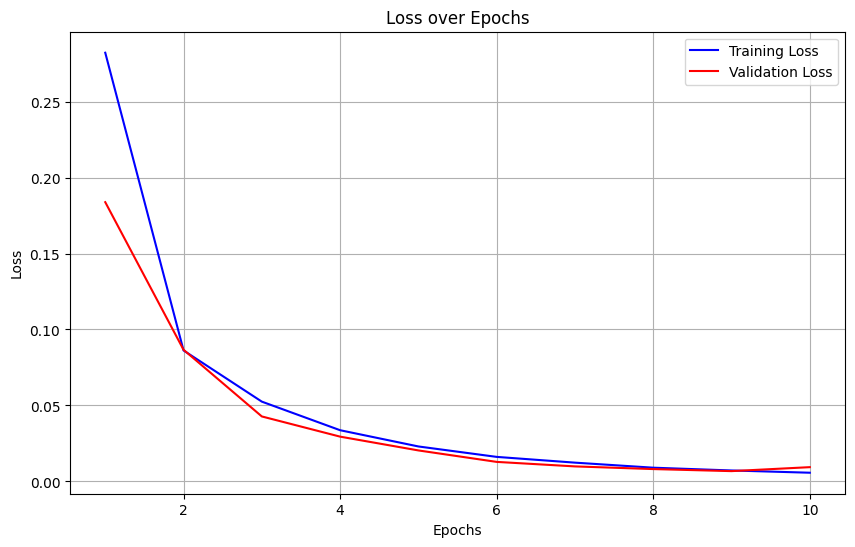

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Model evaluation

In [ ]:
# evaluating the model and calculating the accuracy
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += masks.numel()
        correct += (predicted == masks.unsqueeze(1).float()).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 99.96%


In [ ]:
# Fixed IoU and Dice calculation functions
def calculate_iou(pred, target):
    # Ensure tensors are flattened to 1D for comparison
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection

    # Avoid division by zero
    if union.item() == 0:
        return 1.0 if intersection.item() == 0 else 0.0

    return (intersection / union).item()



model.eval()
with torch.no_grad():
    total_iou = 0

    num_images = 0
    correct = 0
    total_pixels = 0

    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()

        # Account for dimension differences
        if masks.dim() == 3 and predicted.dim() == 4:
            masks = masks.unsqueeze(1)  # Add channel dimension if needed

        # Calculate accuracy
        total_pixels += masks.numel()
        correct += (predicted == masks).sum().item()

        # Calculate IoU and Dice for each image
        for i in range(images.size(0)):
            pred = predicted[i]
            target = masks[i]

            # Debug prints to understand tensor shapes
            # print(f"Pred shape: {pred.shape}, Target shape: {target.shape}")

            total_iou += calculate_iou(pred, target)


        num_images += images.size(0)

    accuracy = correct / total_pixels
    mean_iou = total_iou / num_images


    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print(f"Mean IoU: {mean_iou:.4f}")


Test Accuracy: 99.96%
Mean IoU: 0.8767


In [ ]:
import os

preburn_hdf_dir = '/content/drive/MyDrive/WildfireProject preburn_hdf'

# Check contents of the folder
print("Found files in preburn_hdf:")
print(os.listdir(preburn_hdf_dir))

Found files in preburn_hdf:
['MOD09GA.A2022180.h09v04.061.2022182033640.hdf', 'MOD09GA.A2022189.h08v05.061.2022191041255.hdf', 'MOD09GA.A2022181.h08v05.061.2022183031228.hdf', 'MOD09GA.A2022189.h08v04.061.2022191043930.hdf', 'MOD09GA.A2022181.h08v04.061.2022183031343.hdf', 'MOD09GA.A2022189.h09v04.061.2022191044549.hdf']


In [ ]:
import os
from osgeo import gdal
import numpy as np
import rasterio
from rasterio.transform import from_origin

preburn_hdf_dir = '/content/drive/MyDrive/WildfireProject preburn_hdf'
preburn_tif_dir = '/content/drive/MyDrive/WildfireProject/preburn_tifs'
os.makedirs(preburn_tif_dir, exist_ok=True)

# Band indices for RGB in MOD09GA
band_names = {
    'sur_refl_b01': 0,  # Red
    'sur_refl_b04': 1,  # Green
    'sur_refl_b03': 2   # Blue
}

# Loop through all preburn .hdf files
for filename in os.listdir(preburn_hdf_dir):
    if filename.endswith('.hdf'):
        hdf_path = os.path.join(preburn_hdf_dir, filename)
        print(f" Processing: {filename}")

        # Open the HDF file
        hdf_dataset = gdal.Open(hdf_path)
        if not hdf_dataset:
            print(f"Could not open {filename}, skipping.")
            continue

        # Get subdatasets
        subdatasets = hdf_dataset.GetSubDatasets()
        rgb_bands = {}

        # Look for RGB subdatasets
        for sds_path, sds_name in subdatasets:
            for band_key in band_names:
                if band_key in sds_path:
                    band_array = gdal.Open(sds_path).ReadAsArray()
                    rgb_bands[band_key] = band_array

        # Check if all 3 bands are available
        if len(rgb_bands) < 3:
            print(f"Missing bands in {filename}, skipping.")
            continue

        # Stack into RGB image (C, H, W) → (3, H, W)
        rgb_stack = np.stack([
            rgb_bands['sur_refl_b01'],
            rgb_bands['sur_refl_b04'],
            rgb_bands['sur_refl_b03']
        ])

        # Save to GeoTIFF
        out_path = os.path.join(preburn_tif_dir, filename.replace('.hdf', '.tif'))
        transform = from_origin(0, 0, 1, 1)  # dummy transform

        with rasterio.open(
            out_path,
            'w',
            driver='GTiff',
            height=rgb_stack.shape[1],
            width=rgb_stack.shape[2],
            count=3,
            dtype=rgb_stack.dtype,
            transform=transform
        ) as dst:
            dst.write(rgb_stack)

        print(f"Saved RGB image: {out_path}")


🔍 Processing: MOD09GA.A2022180.h09v04.061.2022182033640.hdf


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022180.h09v04.061.2022182033640.tif
🔍 Processing: MOD09GA.A2022189.h08v05.061.2022191041255.hdf
Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022189.h08v05.061.2022191041255.tif
🔍 Processing: MOD09GA.A2022181.h08v05.061.2022183031228.hdf
Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022181.h08v05.061.2022183031228.tif
🔍 Processing: MOD09GA.A2022189.h08v04.061.2022191043930.hdf
Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022189.h08v04.061.2022191043930.tif
🔍 Processing: MOD09GA.A2022181.h08v04.061.2022183031343.hdf
Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022181.h08v04.061.2022183031343.tif
🔍 Processing: MOD09GA.A2022189.h09v04.061.2022191044549.hdf
Saved RGB image: /content/drive/MyDrive/WildfireProject/preburn_tifs/MOD09GA.A2022189.h09v04.061.2022191044549.tif


In [ ]:
import os
import numpy as np
import rasterio
from tqdm import tqdm

image_dir = '/content/drive/MyDrive/WildfireProject/preburn_tifs'
mask_dir = '/content/drive/MyDrive/WildfireProject/tifs'

tile_img_dir = '/content/drive/MyDrive/WildfireProject/tiles/images'
tile_mask_dir = '/content/drive/MyDrive/WildfireProject/tiles/masks'

os.makedirs(tile_img_dir, exist_ok=True)
os.makedirs(tile_mask_dir, exist_ok=True)

tile_size = 256
stride = 256  # No overlap

# List all available mask files
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.tif')])

# Extract tile ID from filename
def extract_tile_id(filename):
    parts = filename.split('.')
    for part in parts:
        if part.startswith('h') and 'v' in part:
            return part
    return None

image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif')])

for img_file in tqdm(image_files):
    tile_id = extract_tile_id(img_file)
    if not tile_id:
        print(f"Could not extract tile ID from {img_file}")
        continue

    # Finding matching mask with same tile ID
    matching_masks = [f for f in mask_files if tile_id in f]
    if not matching_masks:
        print(f"No mask found for tile {tile_id}, skipping.")
        continue

    # Use the first matching mask (one per tile)
    mask_file = matching_masks[0]

    img_path = os.path.join(image_dir, img_file)
    mask_path = os.path.join(mask_dir, mask_file)

    with rasterio.open(img_path) as img_src:
        img = img_src.read()  # shape: (3, H, W)

    with rasterio.open(mask_path) as mask_src:
        mask = mask_src.read(1)  # shape: (H, W)

    _, H, W = img.shape

    for i in range(0, H - tile_size + 1, stride):
        for j in range(0, W - tile_size + 1, stride):
            tile_img = img[:, i:i+tile_size, j:j+tile_size]
            tile_mask = mask[i:i+tile_size, j:j+tile_size]

            if tile_mask.sum() == 0:
                continue

            base_name = f"{tile_id}_{i}_{j}.tif"

            img_out_path = os.path.join(tile_img_dir, base_name)
            with rasterio.open(
                img_out_path, 'w', driver='GTiff',
                height=tile_size, width=tile_size,
                count=3, dtype=tile_img.dtype
            ) as dst:
                dst.write(tile_img)

            mask_out_path = os.path.join(tile_mask_dir, base_name.replace('.tif', '_mask.tif'))
            with rasterio.open(
                mask_out_path, 'w', driver='GTiff',
                height=tile_size, width=tile_size,
                count=1, dtype=tile_mask.dtype
            ) as dst:
                dst.write(tile_mask, 1)

print("Done, Tiled all matching image-mask pairs.")

  0%|          | 0/6 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
100%|██████████| 6/6 [00:06<00:00,  1.08s/it]

Done, Tiled all matching image-mask pairs.


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Source folders
tile_img_dir = '/content/drive/MyDrive/WildfireProject/tiles/images'
tile_mask_dir = '/content/drive/MyDrive/WildfireProject/tiles/masks'

# Output split folders
base_dir = '/content/drive/MyDrive/WildfireProject/tiles'
splits = ['train', 'val', 'test']

for split in splits:
    os.makedirs(os.path.join(base_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, split, 'masks'), exist_ok=True)

# List all image tiles
image_files = sorted([f for f in os.listdir(tile_img_dir) if f.endswith('.tif')])
random.shuffle(image_files)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

total = len(image_files)
train_count = int(total * train_ratio)
val_count = int(total * val_ratio)

# Split datasets
train_files = image_files[:train_count]
val_files = image_files[train_count:train_count + val_count]
test_files = image_files[train_count + val_count:]

# Helper function to copy files
def copy_files(file_list, split_name):
    for fname in tqdm(file_list, desc=f"Copying to {split_name}"):
        src_img = os.path.join(tile_img_dir, fname)
        src_mask = os.path.join(tile_mask_dir, fname.replace('.tif', '_mask.tif'))

        dst_img = os.path.join(base_dir, split_name, 'images', fname)
        dst_mask = os.path.join(base_dir, split_name, 'masks', fname.replace('.tif', '_mask.tif'))

        if os.path.exists(src_img) and os.path.exists(src_mask):
            shutil.copy2(src_img, dst_img)
            shutil.copy2(src_mask, dst_mask)

# Copy into each split
copy_files(train_files, 'train')
copy_files(val_files, 'val')
copy_files(test_files, 'test')

print("Dataset split complete!")

Copying to test: 100%|██████████| 9/9 [00:02<00:00,  4.37it/s]

Dataset split complete!
